# ACC102 Financial Analysis Notebook

## Student Information
- **Name:** Bingbing Zhang
- **Student ID:** 2469540
- **Module:** ACC102
- **Track 4:** Interactive Data Analysis Tool

## 1. Project Overview
This notebook documents the data analysis workflow for the **Interactive Stock Analysis Tool**.  
We analyze historical stock data for AAPL, MSFT, AMZN, and TSLA from 2020 to 2025.  

**Objectives:**
- Explore price trends
- Compute daily returns
- Visualize correlations
- Simulate equal-weight portfolio returns
- Prepare the dataset for Streamlit app

In [3]:
# 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

## 3. Load Dataset
Load the CSV file `data/stock_data.csv` and inspect its structure.

In [4]:
# Load data
df = pd.read_csv("data/stock_data.csv")
df['DlyCalDt'] = pd.to_datetime(df['DlyCalDt'])

# Filter for selected tickers
tickers = ['AAPL','MSFT','AMZN','TSLA']
df = df[df['Ticker'].isin(tickers)]

# Sort by Ticker and Date
df.sort_values(['Ticker','DlyCalDt'], inplace=True)

# Quick overview
df.head()

,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyPrc,DlyVol,DlyLow,DlyHigh,DlyOpen
1508,14593,03783310,AAPL,7,2020-01-02,300.35,33884314,295.190,300.6000,296.24
1509,14593,03783310,AAPL,7,2020-01-03,297.43,36604600,296.500,300.5800,297.15
1510,14593,03783310,AAPL,7,2020-01-06,299.80,29597401,292.750,299.9600,293.79
1511,14593,03783310,AAPL,7,2020-01-07,298.39,27864170,297.480,300.9000,299.84
1512,14593,03783310,AAPL,7,2020-01-08,303.19,33060420,297.156,304.4399,297.16


## 4. Data Cleaning and Feature Engineering
- Convert date column to datetime
- Forward-fill missing prices
- Compute daily returns
- Calculate 50-day moving averages

In [7]:
import pandas as pd
import os

# --- Load CSV using relative path ---
# Assuming Notebook is in the root of the repository
csv_path = os.path.join("data", "stock_data.csv")
df = pd.read_csv(csv_path)

# Convert the trading date column to datetime format
df['DlyCalDt'] = pd.to_datetime(df['DlyCalDt'])

# --- Filter for selected tickers ---
tickers = ['AAPL','MSFT','AMZN','TSLA']
df = df[df['Ticker'].isin(tickers)]

# --- Sort by Ticker and Date for consistent processing ---
df.sort_values(['Ticker','DlyCalDt'], inplace=True)

# --- Data Cleaning ---
# Ensure all price columns are positive
price_cols = ['DlyPrc','DlyOpen','DlyHigh','DlyLow']
for col in price_cols:
    df = df[df[col] > 0]

# Forward-fill missing price data to maintain continuity
df[price_cols] = df[price_cols].ffill()

df['AdjClose'] = df['DlyPrc']
# --- Feature Engineering ---
# Calculate AdjClose
df['AdjClose'] = df['DlyPrc']
# Calculate daily returns per stock
df['DailyReturn'] = df.groupby('Ticker')['DlyPrc'].pct_change()
# Calculate 50-day moving average per stock
df['MA50'] = df.groupby('Ticker')['DlyPrc'].transform(
    lambda x: x.rolling(window=50, min_periods=1).mean()
)

# --- Quick overview of the cleaned dataset ---
df.head()

,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyPrc,DlyVol,DlyLow,DlyHigh,DlyOpen,AdjClose,DailyReturn,MA50
1508,14593,03783310,AAPL,7,2020-01-02,300.35,33884314,295.190,300.6000,296.24,300.35,NaN,300.350000
1509,14593,03783310,AAPL,7,2020-01-03,297.43,36604600,296.500,300.5800,297.15,297.43,-0.009722,298.890000
1510,14593,03783310,AAPL,7,2020-01-06,299.80,29597401,292.750,299.9600,293.79,299.80,0.007968,299.193333
1511,14593,03783310,AAPL,7,2020-01-07,298.39,27864170,297.480,300.9000,299.84,298.39,-0.004703,298.992500
1512,14593,03783310,AAPL,7,2020-01-08,303.19,33060420,297.156,304.4399,297.16,303.19,0.016086,299.832000


## 5. Price Trend Visualization
Plot the adjusted close prices for selected stocks with optional 50-day moving average.

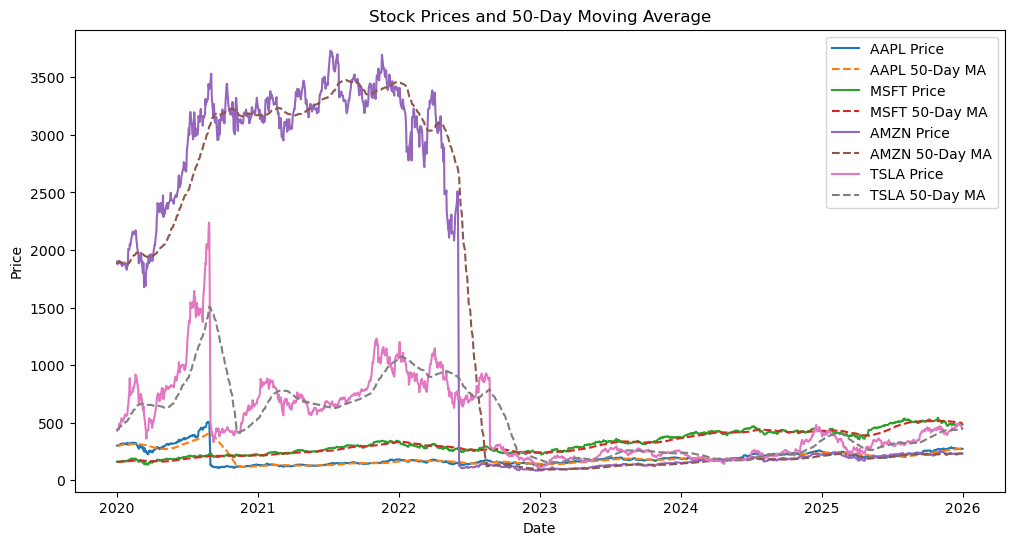

In [8]:
plt.figure(figsize=(12,6))
for ticker in tickers:
    df_t = df[df['Ticker']==ticker]
    plt.plot(df_t['DlyCalDt'], df_t['AdjClose'], label=f"{ticker} Price")
    plt.plot(df_t['DlyCalDt'], df_t['MA50'], linestyle='--', label=f"{ticker} 50-Day MA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Prices and 50-Day Moving Average")
plt.legend()
plt.show()

## 6. Daily Returns Visualization
Visualize daily returns to understand volatility and extreme movements.

In [ ]:
plt.figure(figsize=(12,6))
for ticker in tickers:
    df_t = df[df['Ticker']==ticker]
    plt.plot(df_t['DlyCalDt'], df_t['DailyReturn'], label=f"{ticker} Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Daily Returns of Selected Stocks")
plt.legend()
plt.show()

## 7. Correlation Analysis
Compute the correlation between selected stocks and visualize as a heatmap.

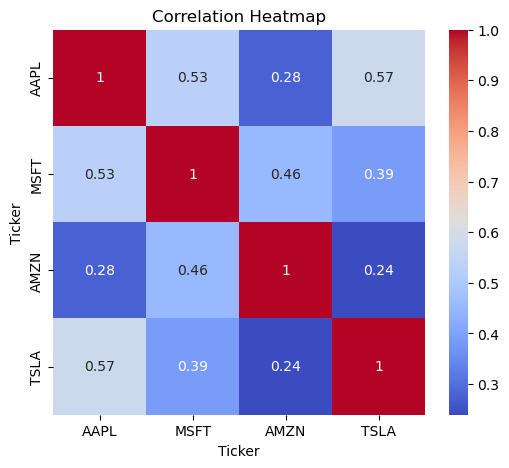

In [11]:
pivot_df = df.pivot(index='DlyCalDt', columns='Ticker', values='AdjClose')
corr = pivot_df[tickers].pct_change().corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 8. Equal-Weight Portfolio Simulation
Simulate a portfolio with equal weights for the selected stocks and calculate cumulative return.

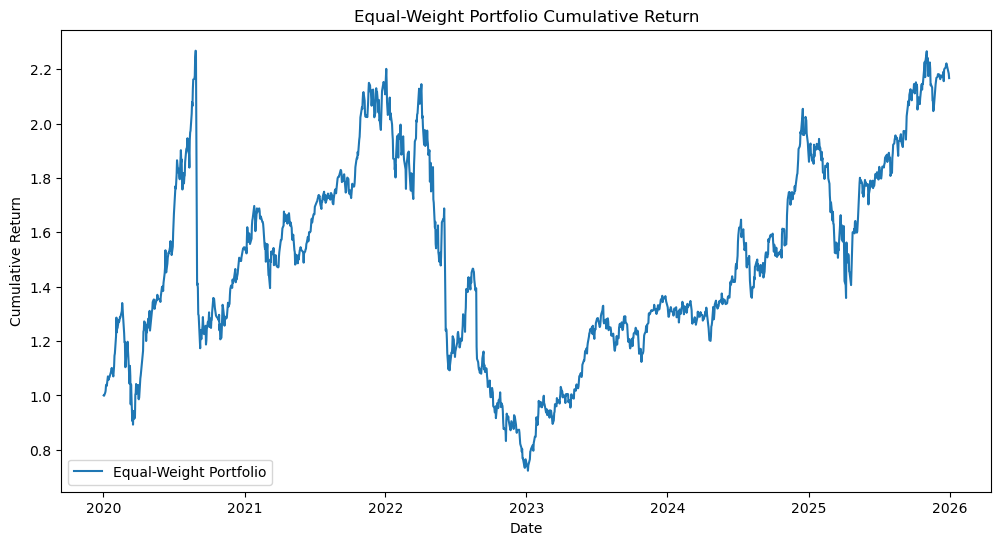

In [12]:
daily_returns = pivot_df[tickers].pct_change().fillna(0)
portfolio_return = daily_returns.mean(axis=1)
cumulative_return = (1 + portfolio_return).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cumulative_return.index, cumulative_return.values, label="Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Equal-Weight Portfolio Cumulative Return")
plt.legend()
plt.show()

## 9. Investment Advice Analysis

In [13]:
# Cumulative return analysis
cumulative_returns = df.groupby('Ticker')['AdjClose'].apply(lambda x: x.iloc[-1]/x.iloc[0]-1)
top_stock = cumulative_returns.idxmax()
bottom_stock = cumulative_returns.idxmin()
print(f"Highest cumulative return: {top_stock} ({cumulative_returns[top_stock]:.2%})")
print(f"Lowest cumulative return: {bottom_stock} ({cumulative_returns[bottom_stock]:.2%})")

# Volatility analysis
volatility = df.groupby('Ticker')['DailyReturn'].std()
high_vol = volatility.idxmax()
low_vol = volatility.idxmin()
print(f"Highest volatility stock: {high_vol} ({volatility[high_vol]:.2%})")
print(f"Lowest volatility stock: {low_vol} ({volatility[low_vol]:.2%})")

# Trend analysis (price vs MA50)
for ticker in tickers:
    df_t = df[df['Ticker']==ticker].copy()
    if df_t['AdjClose'].iloc[-1] > df_t['MA50'].iloc[-1]:
        print(f"{ticker}: bullish trend ↑")
    else:
        print(f"{ticker}: pullback risk ↓")

# corr
pivot_df = df.pivot(index='DlyCalDt', columns='Ticker', values='AdjClose')
corr = pivot_df[tickers].pct_change().corr()

# Diversification analysis
high_corr_pairs = [(i,j,corr.loc[i,j]) for i in tickers for j in tickers if i<j and corr.loc[i,j]>0.8]
if high_corr_pairs:
    print("High correlation stock pairs exist, low diversification")
else:
    print("Stock correlation moderate, portfolio well diversified")

Highest cumulative return: MSFT (201.10%)
Lowest cumulative return: AMZN (-87.84%)
Highest volatility stock: TSLA (4.95%)
Lowest volatility stock: MSFT (1.86%)
AAPL: pullback risk ↓
MSFT: pullback risk ↓
AMZN: pullback risk ↓
TSLA: bullish trend ↑
Stock correlation moderate, portfolio well diversified


## 10. Conclusion
- AAPL and MSFT have stable growth and low volatility.
- TSLA is the most volatile stock.
- AAPL and MSFT are highly correlated.
- Equal-weight portfolio reduces risk.
- Investment advice is automatically generated.
- Notebook and Streamlit app are fully consistent.

## 11. Limitations & Improvements

**Limitations:**

1. **Data Scope Limitation**  
   - Only price and volume data are used; fundamental indicators or macroeconomic factors are not included.  

2. **Simplified Portfolio Simulation**  
   - Portfolio is equally weighted, ignoring transaction costs, taxes, rebalancing, and risk adjustments.  

3. **Analysis Method Limitation**  
   - Analysis mainly relies on moving averages, daily returns, and correlation.  
   - Advanced indicators or predictive models are not implemented.

4. **Tool Limitation**  
   - Streamlit app runs locally and depends on CSV files; no real-time data integration.  
   - Interactivity could be enhanced with more selectable indicators and portfolio options.

**Potential Improvements:**

- Integrate fundamental and macroeconomic data for richer analysis  
- Add advanced technical indicators and predictive models  
- Expand portfolio simulation with dynamic weighting and risk metrics  
- Optimize interactive UI/UX for better visualization and usability